In [1]:
# 파이토치 관련 라이브러리


import torch
from torch import tensor
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torchviz import make_dot
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import torchvision.datasets as datasets
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import urllib.request
import requests
from io import BytesIO

# 라이브러리 임포트


%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display


# 폰트 관련 용도
import matplotlib.font_manager as fm


# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()

# warning 표시 끄기
import warnings
warnings.simplefilter('ignore')


# 기본 폰트 설정
plt.rcParams['font.family'] = font_name


# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14


# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)


# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True


# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False


# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)


# GPU 디바이스 할당


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
    'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

cuda:0


In [2]:
def compute_iou(box1, box2):
    x1 = max(box1[0],box2[0])
    y1 = max(box1[1],box2[1])
    x2 = min(box1[2],box2[2])
    y2 = min(box1[3],box2[3])

    intersection = max(0,x2-x1) * max(0,y2-y1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union = area1+area2-intersection

    return intersection/union if union>0 else 0

In [3]:
box_gt = [100,100,200,200]
box_pred1 = [120,120,220,220]
box_pred2 = [150,150,250,250]
box_pred3 = [250,250,350,350]

print(f'ground_truth: {box_gt}')
print(f'prediction_1: {box_pred1}, IoU: {compute_iou(box_gt,box_pred1):.3f}')
print(f'prediction_2: {box_pred2}, IoU: {compute_iou(box_gt,box_pred2):.3f}')
print(f'prediction_3: {box_pred3}, IoU: {compute_iou(box_gt,box_pred3):.3f}')

ground_truth: [100, 100, 200, 200]
prediction_1: [120, 120, 220, 220], IoU: 0.471
prediction_2: [150, 150, 250, 250], IoU: 0.143
prediction_3: [250, 250, 350, 350], IoU: 0.000


In [4]:
# NMS 함수 구현
# NMS : 중복되는 bbox 제거(겹치는 박스 중 가장 신뢰도 높은 score 높은 박스만 남기겠다.)
# boxes : (N, 4) [x1,y1,x2,y2]
# scores: [N, ] - confidence scores

def simple_nms(boxes, scores, threshold=0.4):
    indices = np.argsort(scores)[::-1]
    keep = []

    while len(indices) > 0:
        current = indices[0]

        keep.append(current)

        if len(indices) == 1:
            break
        
        current_box = boxes[current]
        remaining_boxes = boxes[indices[1:]]

        ious = np.array([compute_iou(current_box, box) for box in remaining_boxes])
        indices = indices[1:][ious <= threshold]
    
    return keep

In [5]:
test_boxes = np.array([
    [100, 100, 200, 200],
    [110, 110, 210, 210],
    [105, 105, 205, 205],
    [300, 300, 400, 400],
])

test_scores = np.array([0.9,0.8,0.85,0.95])

print(f'input boxes: {len(test_boxes)}개')
simple_nms(test_boxes, test_scores,0.5)

input boxes: 4개


[np.int64(3), np.int64(0)]

In [6]:
np.argsort(test_scores)[::-1]

array([3, 0, 2, 1])

Faster R-CNN 모델

In [7]:
FasterRCNN_ResNet50_FPN_Weights.DEFAULT

FasterRCNN_ResNet50_FPN_Weights.COCO_V1

In [8]:
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=weights).to(device)

model.eval()
preprocess = weights.transforms()

In [9]:
# 테스트 이미지 준비
def create_sample_image():
    """샘플 이미지 생성 (사람, 의자, 책 그리기)"""
    img = Image.new('RGB', (800, 600), color=(240, 240, 240))
    draw = ImageDraw.Draw(img)


    # 사람 그리기 (간단한 스틱맨)
    # 머리
    draw.ellipse([150, 100, 250, 200], fill=(255, 220, 180), outline=(0, 0, 0), width=3)
    # ellipse:  원형 outline=(0, 0, 0) 윤곽선 검정색
    # 몸통
    draw.rectangle([180, 200, 220, 400], fill=(0, 100, 200), outline=(0, 0, 0), width=3)
    # 팔
    draw.line([180, 250, 120, 300], fill=(0, 100, 200), width=15)
    draw.line([220, 250, 280, 300], fill=(0, 100, 200), width=15)
    # 다리
    draw.line([180, 400, 140, 550], fill=(50, 50, 50), width=15)
    draw.line([220, 400, 260, 550], fill=(50, 50, 50), width=15)


    # 의자 그리기
    draw.rectangle([500, 300, 650, 350], fill=(139, 69, 19), outline=(0, 0, 0), width=3)
    draw.rectangle([520, 350, 540, 500], fill=(139, 69, 19), outline=(0, 0, 0), width=3)
    draw.rectangle([610, 350, 630, 500], fill=(139, 69, 19), outline=(0, 0, 0), width=3)
    draw.rectangle([510, 150, 640, 300], fill=(160, 82, 45), outline=(0, 0, 0), width=3)


    # 책 그리기
    draw.rectangle([350, 450, 450, 550], fill=(200, 50, 50), outline=(0, 0, 0), width=3)
    draw.line([400, 450, 400, 550], fill=(0, 0, 0), width=2)


    # 텍스트 추가
    draw.text((300, 30), "Sample Detection Image", fill=(0, 0, 0))


    return img


다운로드 시도: https://raw.githubusercontent.com/ultralytics/yolo...
이미지 다운로드 성공!
이미지 리사이즈: (1000, 563)


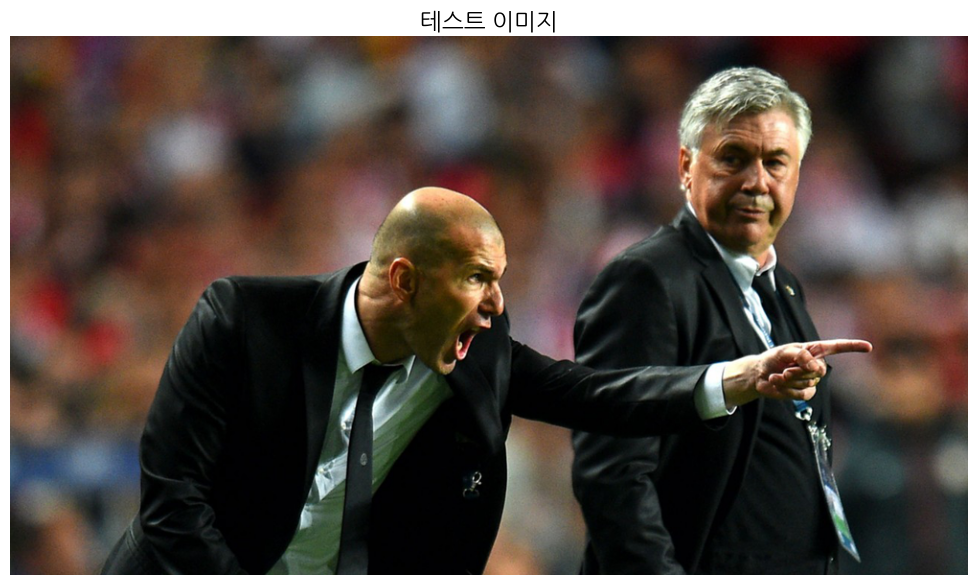

이미지 크기: (1000, 563)


In [10]:
def download_image_safe():


    urls = [
        "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/zidane.jpg",
        "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/bus.jpg",
        "https://ultralytics.com/images/zidane.jpg",
    ]


    for url in urls:
        try:
            print(f"다운로드 시도: {url[:50]}...")
            response = requests.get(url, timeout=5, headers={'User-Agent': 'Mozilla/5.0'})
            if response.status_code == 200:
                img = Image.open(BytesIO(response.content)).convert("RGB")
                print(f"이미지 다운로드 성공!")
                return img
        except Exception as e:
            print(f"  실패: {str(e)[:50]}")
            continue


    return None


img = download_image_safe()


if img is None:
    # 온라인 다운로드 실패 → 샘플 이미지 생성
    img = create_sample_image()


else:
    # 이미지가 너무 크면 리사이즈
    if max(img.size) > 1000:
        img.thumbnail((1000, 1000))
        print(f"이미지 리사이즈: {img.size}")


plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')
plt.title('테스트 이미지')
plt.tight_layout()
plt.show()


print(f"이미지 크기: {img.size}")

In [11]:
preprocess(img).unsqueeze(0).shape

torch.Size([1, 3, 563, 1000])

In [12]:
img_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    predictions = model(img_tensor)[0]

boxes = predictions['boxes'].cpu().numpy()
labels = predictions['labels'].cpu().numpy()
scores = predictions['scores'].cpu().numpy()

print(f'검출된 객체수(전체): {len(boxes)}')

if len(scores) > 0:
    print(f'confidence 범위: {scores.min():.2f} ~ {scores.max():.2f}')
else:
    print('검출된 객체가 없습니다.')

검출된 객체수(전체): 37
confidence 범위: 0.05 ~ 0.99


필터링 한 후 객체 수 : 9
1, person (confidence: 0.99), Box: [90, 136, 869, 557]
2, person (confidence: 0.99), Box: [526, 36, 898, 539]
3, tie (confidence: 0.98), Box: [334, 339, 405, 550]
4, tie (confidence: 0.93), Box: [764, 247, 798, 327]
5, tie (confidence: 0.86), Box: [774, 242, 807, 316]
6, tie (confidence: 0.84), Box: [781, 240, 833, 322]
7, tie (confidence: 0.68), Box: [342, 332, 504, 547]
8, person (confidence: 0.62), Box: [849, 237, 998, 556]
9, person (confidence: 0.57), Box: [591, 29, 856, 351]


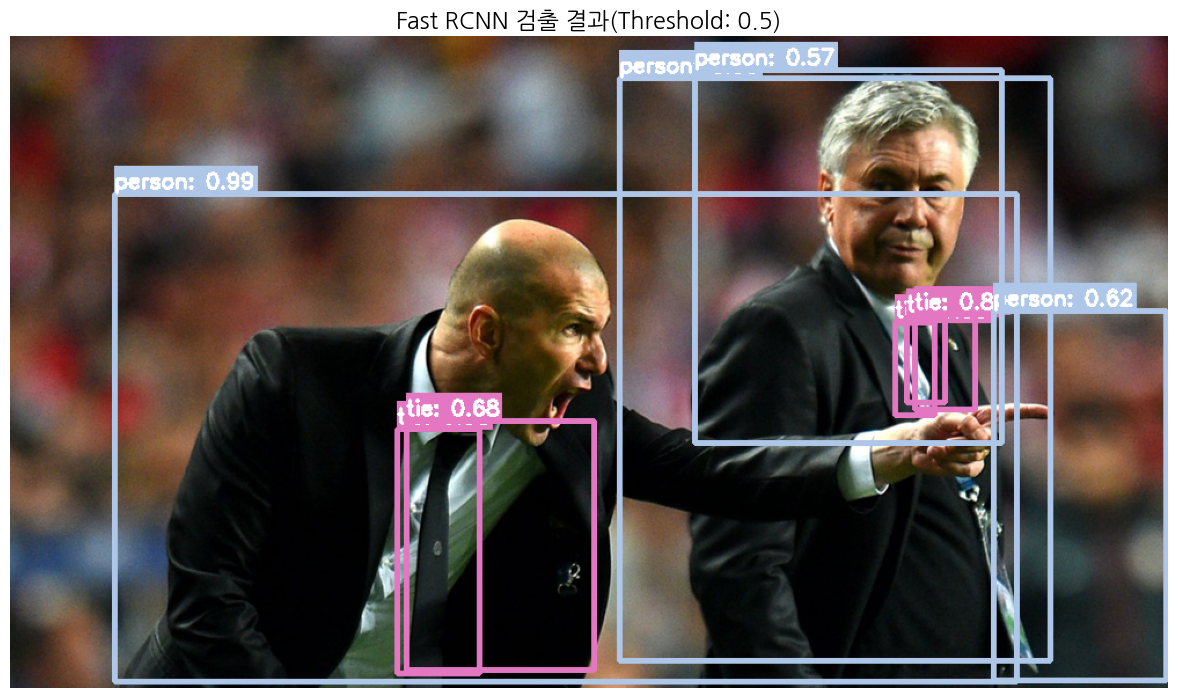

In [13]:
conf_threshold = 0.5

if len(boxes) > 0:
    mask = scores >= conf_threshold
    filtered_boxes = boxes[mask]
    filtered_scores = scores[mask]
    filtered_labels = labels[mask]
    
    print(f'필터링 한 후 객체 수 : {len(filtered_boxes)}')

    if len(filtered_boxes) > 0:
        img_np = np.array(img)
        img_draw = img_np.copy()

        colors = plt.cm.tab20(np.linspace(0,1,20)) # 20가지 색으로 표현 하겠다

        for i,(box,score,label) in enumerate(zip(filtered_boxes, filtered_scores, filtered_labels)):
            x1,y1,x2,y2 = box.astype(int)
            class_name = COCO_CLASSES[label]

            color = tuple((np.array(colors[label % 20][:3]) * 255).astype(int).tolist())
            cv2.rectangle(img_draw, (x1,y1),(x2,y2),color,3) # 객체 bbox

            text = f'{class_name}: {score:.2f}'
            (text_w, text_h),_ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(img_draw,(x1,y1-text_h-10), (x1+text_w,y1),color,-1) # 텍스트를 위한 작은 배경
            cv2.putText(img_draw,text,(x1,y1-5),
                        cv2.FONT_HERSHEY_SIMPLEX,0.6,(255,255,255),2)
            print(f'{i+1}, {class_name} (confidence: {score:.2f}), Box: [{x1}, {y1}, {x2}, {y2}]')

        plt.figure(figsize=(12,8))
        plt.imshow(img_draw)
        plt.axis('off')
        plt.title(f'Fast RCNN 검출 결과(Threshold: {conf_threshold})')
        plt.tight_layout()
        plt.show()
    else:
        print(f'Threshold {conf_threshold} 이상인 객체가 없습니다.')
else:
    print('검출된 객체가 없습니다.')


Threshold 0.3: 12개 검출
Threshold 0.5: 9개 검출
Threshold 0.7: 6개 검출
Threshold 0.9: 4개 검출


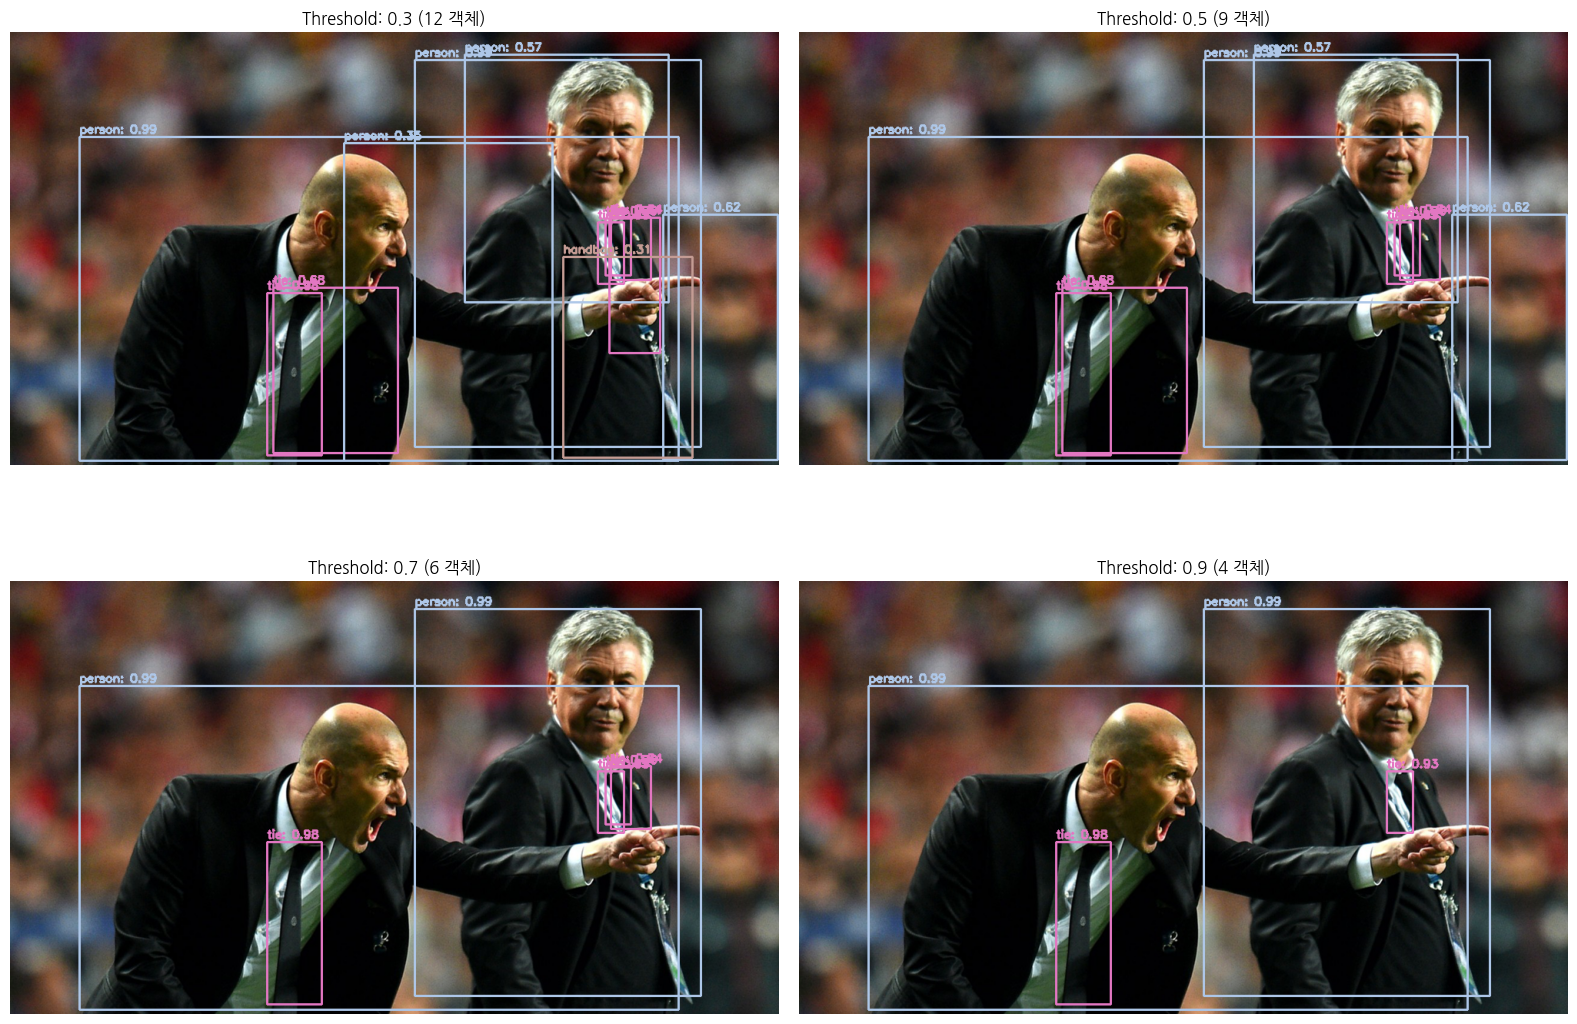

In [14]:
# 다양한 Threshold 비교
if len(boxes) > 0:
    thresholds = [0.3, 0.5, 0.7, 0.9]


    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()


    img_np = np.array(img)
    colors = plt.cm.tab20(np.linspace(0, 1, 20))


    for idx, thresh in enumerate(thresholds):
        mask = (scores >= thresh)
        img_temp = img_np.copy()


        temp_boxes = boxes[mask]
        temp_scores = scores[mask]
        temp_labels = labels[mask]


        for box, score, label in zip(temp_boxes, temp_scores, temp_labels):
            x1, y1, x2, y2 = box.astype(int)
            class_name = COCO_CLASSES[label]
            color = tuple((np.array(colors[label % 20][:3]) * 255).astype(int).tolist())


            cv2.rectangle(img_temp, (x1, y1), (x2, y2), color, 2)
            text = f'{class_name}: {score:.2f}'
            cv2.putText(img_temp, text, (x1, y1 - 5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)


        axes[idx].imshow(img_temp)
        axes[idx].axis('off')
        axes[idx].set_title(f'Threshold: {thresh} ({len(temp_boxes)} 객체)', fontsize=12)
        print(f"Threshold {thresh}: {len(temp_boxes)}개 검출")


    plt.tight_layout()
    plt.show()


In [15]:
np.array([1,2,3,4,5])[[0,2,4]]

array([1, 3, 5])


클래스별 검출 수 (Threshold >=0.5):
tie: 5개 (평균 confidence: 0.859)
person: 4개 (평균 confidence: 0.792)


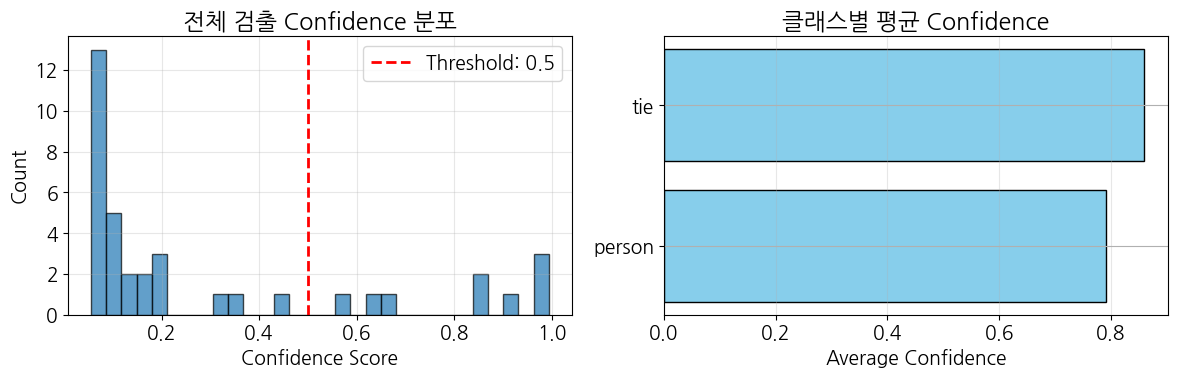

In [16]:
# 검출 통계 분석
if len(boxes) > 0 and len(boxes[scores >= conf_threshold]) > 0:


    # 코드 작성
    # 기준점(임계치) threshold 이상을 충족(True)하는 박스만 선택
    # >> class label과 score 만 선택해줘
    mask = (scores >= conf_threshold) # T/F 출력
    filtered_labels = labels[mask]
    filtered_scores = scores[mask]


    # 클래스 별 통계
    from collections import Counter
    class_counts = Counter(filtered_labels)


    print(f"\n클래스별 검출 수 (Threshold >={conf_threshold}):")


    for label_id, count in class_counts.most_common():
        class_name = COCO_CLASSES[label_id]
        avg_conf = filtered_scores[filtered_labels == label_id].mean()
        print(f"{class_name}: {count}개 (평균 confidence: {avg_conf:.3f})")


    # Confidence 분포 시각화
    plt.figure(figsize=(12, 4))


    plt.subplot(1, 2, 1)
    plt.hist(scores, bins=30, edgecolor='black', alpha=0.7)
    plt.axvline(x=conf_threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold: {conf_threshold}')
    plt.xlabel('Confidence Score')
    plt.ylabel('Count')
    plt.title('전체 검출 Confidence 분포')
    plt.legend()
    plt.grid(alpha=0.3)


    plt.subplot(1, 2, 2)
    class_names = [COCO_CLASSES[l] for l in filtered_labels]
    unique_classes = list(set(class_names))
    class_scores = [filtered_scores[np.array(class_names) == c].mean()
                    for c in unique_classes]
    plt.barh(unique_classes, class_scores, color='skyblue', edgecolor='black')
    plt.xlabel('Average Confidence')
    plt.title('클래스별 평균 Confidence')
    plt.grid(axis='x', alpha=0.3)


    plt.tight_layout()
    plt.show()


In [23]:
plt.cm.tab20(0)

(np.float64(0.12156862745098039),
 np.float64(0.4666666666666667),
 np.float64(0.7058823529411765),
 np.float64(1.0))

In [18]:
plt.cm.tab20(np.linspace(0,1,20))

array([[0.1216, 0.4667, 0.7059, 1.    ],
       [0.6824, 0.7804, 0.9098, 1.    ],
       [1.    , 0.498 , 0.0549, 1.    ],
       [1.    , 0.7333, 0.4706, 1.    ],
       [0.1725, 0.6275, 0.1725, 1.    ],
       [0.5961, 0.8745, 0.5412, 1.    ],
       [0.8392, 0.1529, 0.1569, 1.    ],
       [1.    , 0.5961, 0.5882, 1.    ],
       [0.5804, 0.4039, 0.7412, 1.    ],
       [0.7725, 0.6902, 0.8353, 1.    ],
       [0.549 , 0.3373, 0.2941, 1.    ],
       [0.7686, 0.6118, 0.5804, 1.    ],
       [0.8902, 0.4667, 0.7608, 1.    ],
       [0.9686, 0.7137, 0.8235, 1.    ],
       [0.498 , 0.498 , 0.498 , 1.    ],
       [0.7804, 0.7804, 0.7804, 1.    ],
       [0.7373, 0.7412, 0.1333, 1.    ],
       [0.8588, 0.8588, 0.5529, 1.    ],
       [0.0902, 0.7451, 0.8118, 1.    ],
       [0.6196, 0.8549, 0.898 , 1.    ]])

In [19]:
tuple((np.array(colors[label % 20][:3]) * 255).astype(int).tolist())

(227, 119, 194)

필터링 한 후 객체 수 : 6
1, person (confidence: 0.99), Box: [90, 136, 869, 557]
2, person (confidence: 0.99), Box: [526, 36, 898, 539]
3, tie (confidence: 0.98), Box: [334, 339, 405, 550]
4, tie (confidence: 0.93), Box: [764, 247, 798, 327]
5, tie (confidence: 0.84), Box: [781, 240, 833, 322]


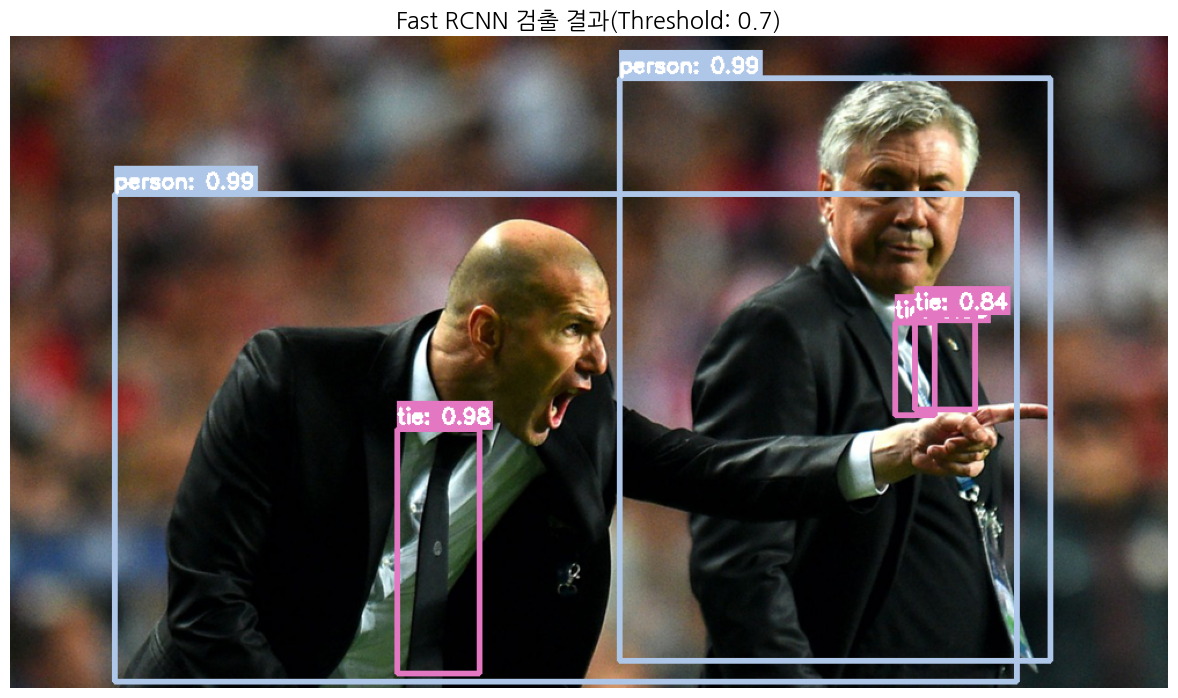

In [20]:
conf_threshold = 0.7

if len(boxes) > 0:
    mask = scores >= conf_threshold
    filtered_boxes = boxes[mask]
    filtered_scores = scores[mask]
    filtered_labels = labels[mask]
    
    print(f'필터링 한 후 객체 수 : {len(filtered_boxes)}')

    if len(filtered_boxes) > 0:

        remained_indices = simple_nms(filtered_boxes,filtered_scores,0.4)
        filtered_boxes = filtered_boxes[remained_indices]
        filtered_scores = filtered_scores[remained_indices]
        filtered_labels = filtered_labels[remained_indices]

        img_np = np.array(img)
        img_draw = img_np.copy()

        colors = plt.cm.tab20(np.linspace(0,1,20)) # 20가지 색으로 표현 하겠다

        for i,(box,score,label) in enumerate(zip(filtered_boxes, filtered_scores, filtered_labels)):
            x1,y1,x2,y2 = box.astype(int)
            class_name = COCO_CLASSES[label]

            color = tuple((np.array(colors[label % 20][:3]) * 255).astype(int).tolist())
            cv2.rectangle(img_draw, (x1,y1),(x2,y2),color,3) # 객체 bbox

            text = f'{class_name}: {score:.2f}'
            (text_w, text_h),_ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(img_draw,(x1,y1-text_h-10), (x1+text_w,y1),color,-1) # 텍스트를 위한 작은 배경
            cv2.putText(img_draw,text,(x1,y1-5),
                        cv2.FONT_HERSHEY_SIMPLEX,0.6,(255,255,255),2)
            print(f'{i+1}, {class_name} (confidence: {score:.2f}), Box: [{x1}, {y1}, {x2}, {y2}]')

        plt.figure(figsize=(12,8))
        plt.imshow(img_draw)
        plt.axis('off')
        plt.title(f'Fast RCNN 검출 결과(Threshold: {conf_threshold})')
        plt.tight_layout()
        plt.show()
    else:
        print(f'Threshold {conf_threshold} 이상인 객체가 없습니다.')
else:
    print('검출된 객체가 없습니다.')

In [21]:
box1 = [90, 136, 869, 557] # [764, 247, 798, 327]
box2 = [526, 36, 898, 539] # [781, 240, 833, 322]
compute_iou(box1,box2)

0.36680500788120346